In [1]:
# AI4I 2020 데이터 이해 + 통계 + 시각화 + 전처리

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from pathlib import Path
from IPython.display import display
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
# 0. 환경 설정
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.3f}".format)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid")

In [6]:
# 한글깨짐 해결, 원인:디폴트 영문글꼴==>한글글꼴
import matplotlib.pyplot as plt
import platform
if platform.system() == 'Windows': # W:대문자
    plt.rcParams['font.family'] = 'Malgun Gothic' # M,G:대문자, 중간에 스페이스 한칸
elif platform.system() == 'Darwin': # 맥OS, D:대문자
    plt.rcParams['font.family'] = 'AppleGothic'
else: # 리눅스
    plt.rcParams['font.family'] = 'NanumGothic'
# -(마이너스 기호) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [7]:
# 폴더 준비
data_dir = Path("data")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

In [8]:
# 1. 데이터 읽기
file_path = data_dir / "ai4i2020.csv"
df = pd.read_csv(file_path)
print(df.shape) # (10000, 14) : (행, 열)
display(df)

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.800,308.400,1604,29.500,14,0,0,0,0,0,0
9996,9997,H39410,H,298.900,308.400,1632,31.800,17,0,0,0,0,0,0
9997,9998,M24857,M,299.000,308.600,1645,33.400,22,0,0,0,0,0,0
9998,9999,H39412,H,299.000,308.700,1408,48.500,25,0,0,0,0,0,0


In [9]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [10]:
# 2. 컬럼명 정리 : 모두 소문자, 간결하게
df.columns = [
    "udi",
    "product_id",
    "type",
    "air_temp_k",
    "process_temp_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "machine_failure",
    "twf",
    "hdf",
    "pwf",
    "osf",
    "rnf"
]

display(pd.DataFrame({"column_name": df.columns}))

,column_name
0,udi
1,product_id
2,type
3,air_temp_k
4,process_temp_k
5,rotational_speed_rpm
6,torque_nm
7,tool_wear_min
8,machine_failure
9,twf


# 3. 컬럼 의미 설명

본 데이터셋의 각 컬럼별 상세 정의와 데이터 분석 시 주목해야 할 해석 포인트입니다.

| 컬럼명 | 의미 | 해석 포인트 |
|:--- |:--- |:--- |
| **udi** | 행 고유 번호 | 데이터 식별용 |
| **product_id** | 제품 ID | 앞 글자가 `type`과 연결되는지 확인 가능 |
| **type** | 제품 품질 등급(L/M/H) | 범주형 변수, 품질 그룹별 비교의 핵심 |
| **air_temp_k** | 공기 온도(K) | 주변 환경 온도 상태 변수 |
| **process_temp_k** | 공정 온도(K) | 실제 공정 진행 중 환경 상태 변수 |
| **rotational_speed_rpm** | 회전 속도(rpm) | 장비의 물리적 동작 상태를 나타냄 |
| **torque_nm** | 토크(Nm) | 장비에 걸리는 부하 특성과 관련 |
| **tool_wear_min** | 공구 마모 시간(분) | 유지보수 및 부품 교체 주기와 직결됨 |
| **machine_failure** | 기계 고장 여부(0/1) | **분석의 타깃(Target) 변수** |
| **twf** | Tool Wear Failure | 세부 고장 유형: 공구 마모로 인한 고장 |
| **hdf** | Heat Dissipation Failure | 세부 고장 유형: 열 방출 문제로 인한 고장 |
| **pwf** | Power Failure | 세부 고장 유형: 전력/동력 관련 고장 |
| **osf** | Overstrain Failure | 세부 고장 유형: 과부하 및 무리한 사용 관련 고장 |
| **rnf** | Random Failure | 세부 고장 유형: 특정할 수 없는 무작위성 고장 |

---

### 💡 주요 해설
* **종합 고장 지표:** `machine_failure`는 전체적인 고장 유무를 나타내는 가장 중요한 변수입니다.
* **고장 원인 분석:** `twf`부터 `rnf`까지의 변수들은 고장의 구체적인 원인을 분류하고 있어, 원인별 예측 모델을 만들 때 유용합니다.
* **핵심 피처:** `type`은 제품군에 따른 내구도 차이를 보여줄 수 있으며, `tool_wear_min`은 현업에서 예방 정비 기준을 세우는 데 핵심적인 역할을 합니다.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   udi                   10000 non-null  int64  
 1   product_id            10000 non-null  object 
 2   type                  10000 non-null  object 
 3   air_temp_k            10000 non-null  float64
 4   process_temp_k        10000 non-null  float64
 5   rotational_speed_rpm  10000 non-null  int64  
 6   torque_nm             10000 non-null  float64
 7   tool_wear_min         10000 non-null  int64  
 8   machine_failure       10000 non-null  int64  
 9   twf                   10000 non-null  int64  
 10  hdf                   10000 non-null  int64  
 11  pwf                   10000 non-null  int64  
 12  osf                   10000 non-null  int64  
 13  rnf                   10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ MB


In [12]:
print("결측치 개수")
display(df.isnull().sum().to_frame("null_count"))

결측치 개수


,null_count
udi,0
product_id,0
type,0
air_temp_k,0
process_temp_k,0
rotational_speed_rpm,0
torque_nm,0
tool_wear_min,0
machine_failure,0
twf,0


In [13]:
print("전체 중복 행 수:", df.duplicated().sum())
print("udi 중복 수:", df["udi"].duplicated().sum())

전체 중복 행 수: 0
udi 중복 수: 0


In [14]:
# 5. 기초 통계
# 수치형 변수의 범위, 평균, 분산감을 익히게 하는 구간
num_cols = [
    "air_temp_k",
    "process_temp_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min"
]

print("수치형 변수 기초 통계")
display(df[num_cols].describe().T)

수치형 변수 기초 통계


,count,mean,std,min,25%,50%,75%,max
air_temp_k,10000.000,300.005,2.000,295.300,298.300,300.100,301.500,304.500
process_temp_k,10000.000,310.006,1.484,305.700,308.800,310.100,311.100,313.800
rotational_speed_rpm,10000.000,1538.776,179.284,1168.000,1423.000,1503.000,1612.000,2886.000
torque_nm,10000.000,39.987,9.969,3.800,33.200,40.100,46.800,76.600
tool_wear_min,10000.000,107.951,63.654,0.000,53.000,108.000,162.000,253.000


In [15]:
print("추가 통계(왜도/첨도)")
extra_stats = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "std": df[num_cols].std(),
    "skew": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurtosis()
}).round(3)

display(extra_stats)

추가 통계(왜도/첨도)


,mean,std,skew,kurtosis
air_temp_k,300.005,2.000,0.114,-0.836
process_temp_k,310.006,1.484,0.015,-0.500
rotational_speed_rpm,1538.776,179.284,1.993,7.393
torque_nm,39.987,9.969,-0.010,-0.013
tool_wear_min,107.951,63.654,0.027,-1.167


### 통계 해석 포인트
- mean: 평균 수준
- std: 값의 퍼짐 정도
- skew: 분포가 한쪽으로 치우쳤는지
- kurtosis: 꼬리 두께나 뾰족함 정도
- tool_wear_min은 비교적 넓은 범위를 가지므로, 구간화해서 보면 해석이 쉬워집니다.

## 📊 데이터 분포 분석 (왜도 및 첨도 해석)

주요 수치형 변수들에 대한 기초 통계량과 분포의 비대칭성(왜도), 뾰족함(첨도)을 분석한 결과입니다.

### 1. 통계 요약표
| 컬럼명 | Mean | Std | Skew (왜도) | Kurtosis (첨도) |
|:--- |:---:|:---:|:---:|:---:|
| **air_temp_k** | 300.005 | 2.000 | 0.114 | -0.836 |
| **process_temp_k** | 310.006 | 1.484 | 0.015 | -0.500 |
| **rotational_speed_rpm** | 1538.776 | 179.284 | **1.993** | **7.393** |
| **torque_nm** | 39.987 | 9.969 | -0.010 | -0.013 |
| **tool_wear_min** | 107.951 | 63.654 | 0.027 | -1.167 |

---

### 2. 주요 변수별 상세 해석

#### ✅ 정규분포에 가까운 변수 (안정적)
* **air_temp_k / process_temp_k**: 왜도와 첨도가 모두 0에 가깝습니다. 온도는 매우 일정한 규칙성을 가지고 정규분포를 따르며 분포하고 있습니다.
* **torque_nm**: 왜도(-0.010)와 첨도(-0.013)가 거의 0에 수렴합니다. 가장 이상적인 종 모양의 분포를 보이며 데이터의 치우침이 없습니다.

#### ⚠️ 주의 깊게 관찰해야 할 변수 (특이치 존재)
* **rotational_speed_rpm**: 
    * **왜도(1.993)**: 양의 왜도로 오른쪽 꼬리가 매우 깁니다. 대부분의 장비는 평균 속도 대역에서 작동하지만, 가끔 **매우 높은 회전 속도**가 발생하는 구간이 존재합니다.
    * **첨도(7.393)**: 분포가 매우 뾰족하며 중앙에 밀집되어 있습니다. 이는 평균에서 크게 벗어난 **강력한 이상치(Outliers)**가 존재할 가능성이 높음을 시사합니다.

#### 🟦 평평한 분포 (균등 분포)
* **tool_wear_min**: 첨도가 **-1.167**로 낮게 나타납니다. 이는 데이터가 중앙에 몰려 있지 않고 0부터 최대치까지 비교적 고르게 퍼져 있음을 의미합니다. 공구 마모가 단계별로 일정하게 누적 기록되었음을 알 수 있습니다.

---

### 💡 데이터 분석 인사이트
1. **데이터 전처리 필요성**: `rotational_speed_rpm`은 높은 왜도와 첨도를 보이므로, 머신러닝 모델 학습 전 로그 변환(Log Transform)이나 이상치 처리를 검토해야 합니다.
2. **특징 추출(Feature Engineering)**: 온도와 토크는 분포가 매우 안정적이므로 표준화(Standardization)를 통해 모델의 성능을 높일 수 있습니다.
3. **고장 예측과의 연결**: 회전 속도(RPM)의 이상치 구간이 실제 `machine_failure`와 연관이 있는지 집중 분석이 필요합니다.

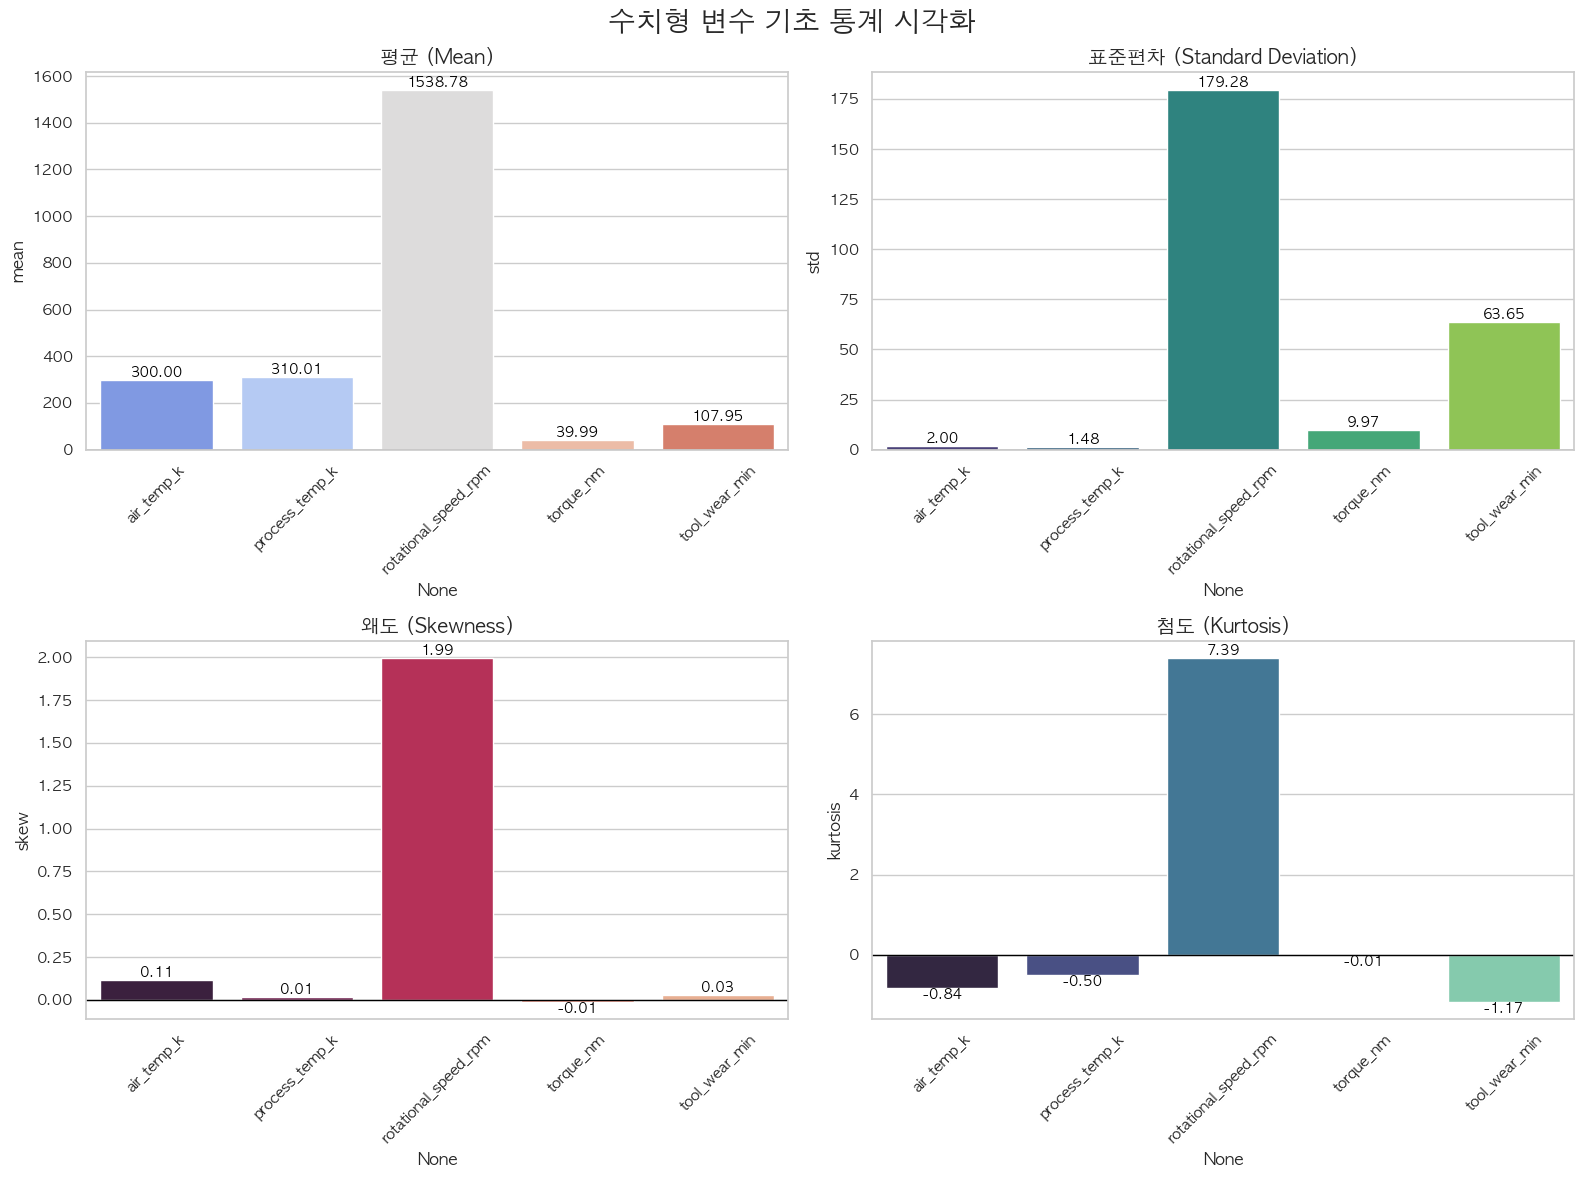

In [16]:
plt.figure(figsize=(16, 12))
plt.suptitle('수치형 변수 기초 통계 시각화', fontsize=20, fontweight='bold')

# 1. 평균 (Mean)
plt.subplot(221)
ax = sns.barplot(x=extra_stats.index, y=extra_stats['mean'], palette='coolwarm')
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2f}", fontsize=10, color="black", fontweight="bold")
plt.title('평균 (Mean)', fontsize=14)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=1)

# 2. 표준편차 (Std)
plt.subplot(222)
ax = sns.barplot(x=extra_stats.index, y=extra_stats['std'], palette='viridis')
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2f}", fontsize=10, color="black", fontweight="bold")
plt.title('표준편차 (Standard Deviation)', fontsize=14)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=1)

# 3. 왜도 (Skewness)
plt.subplot(223)
ax = sns.barplot(x=extra_stats.index, y=extra_stats['skew'], palette='rocket')
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2f}", fontsize=10, color="black", fontweight="bold")
plt.title('왜도 (Skewness)', fontsize=14)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=1)

# 4. 첨도 (Kurtosis)
plt.subplot(224)
ax = sns.barplot(x=extra_stats.index, y=extra_stats['kurtosis'], palette='mako')
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2f}", fontsize=10, color="black", fontweight="bold")
plt.title('첨도 (Kurtosis)', fontsize=14)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

In [17]:
# 6. 범주형 변수 확인
print("제품 type 분포")
display(df["type"].value_counts().to_frame("count"))

제품 type 분포


,count
type,
L,6000
M,2997
H,1003


In [18]:
display(df["type"].value_counts(normalize=True).mul(100).round(2).to_frame("percent"))

,percent
type,
L,60.000
M,29.970
H,10.030


In [19]:
print("기계 고장 여부 분포")
display(df["machine_failure"].value_counts().to_frame("count"))
display(df["machine_failure"].value_counts(normalize=True).mul(100).round(3).to_frame("percent"))

기계 고장 여부 분포


,count
machine_failure,
0,9661
1,339


,percent
machine_failure,
0,96.610
1,3.390


In [20]:
print("세부 고장 유형 합계")
failure_cols = ["twf", "hdf", "pwf", "osf", "rnf"]
display(df[failure_cols].sum().sort_values(ascending=False).to_frame("count"))

세부 고장 유형 합계


,count
hdf,115
osf,98
pwf,95
twf,46
rnf,19


### 해석:
- machine_failure=1의 비율이 낮다면 불균형 데이터입니다.
- 제조 데이터에서는 고장이 자주 발생하지 않는 경우가 많아, 이런 형태가 흔합니다.
- 따라서 이후 모델링에서는 accuracy만 보면 오해할 수 있습니다.

In [21]:
# 7. product_id와 type 관계 확인
df["product_code"] = df["product_id"].str[0]
df["type_match"] = np.where(df["type"] == df["product_code"], 1, 0)

print("product_id 앞 글자와 type 비교")
cross_tab = pd.crosstab(df["type"], df["product_code"])
display(cross_tab)

product_id 앞 글자와 type 비교


product_code,H,L,M
type,,,
H,1003,0,0
L,0,6000,0
M,0,0,2997


In [22]:
print("type_match 분포")
display(df["type_match"].value_counts().to_frame("count"))

type_match 분포


,count
type_match,
1,10000


### 해석:
- product_id의 첫 글자와 type이 일치하면, product_id에 제품 등급 정보가 일부 포함되어 있다고 볼 수 있습니다.
- 이런 확인은 실무에서 컬럼 간 규칙성을 점검할 때 유용합니다.

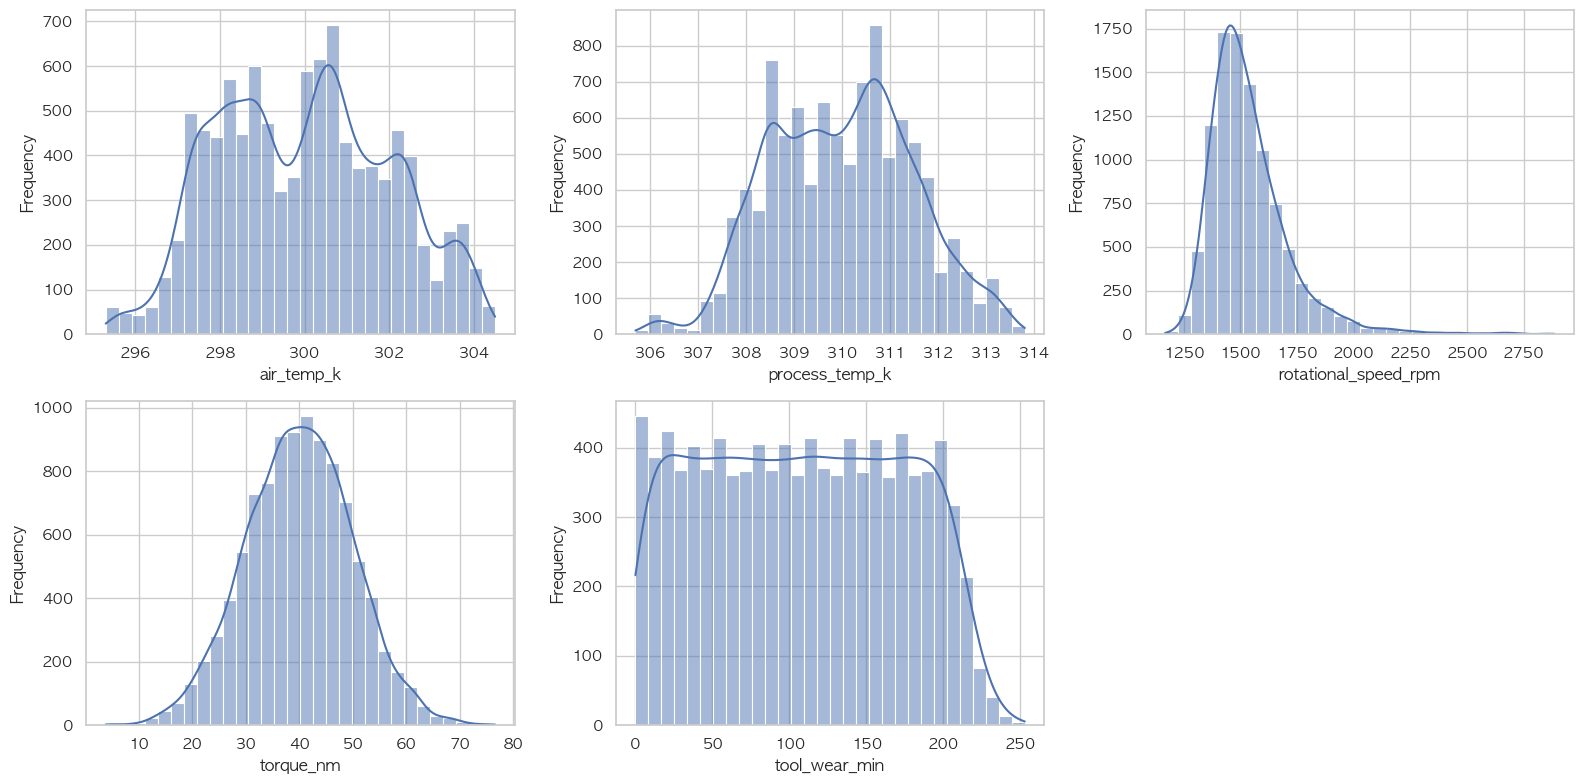

In [23]:
plt.figure(figsize=(16, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data=df, x=col, bins=30, kde=True) # 히스토그램 및 KDE(밀도 곡선) 시각화
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 히스토그램 해석 포인트
- 각 변수의 값이 어느 구간에 많이 몰려 있는지 볼 수 있습니다.
- 분포가 한쪽으로 치우치거나, 여러 봉우리가 보이면 추가 해석이 필요할 수 있습니다.
- kde 곡선은 전체 분포 흐름을 부드럽게 보여줍니다.

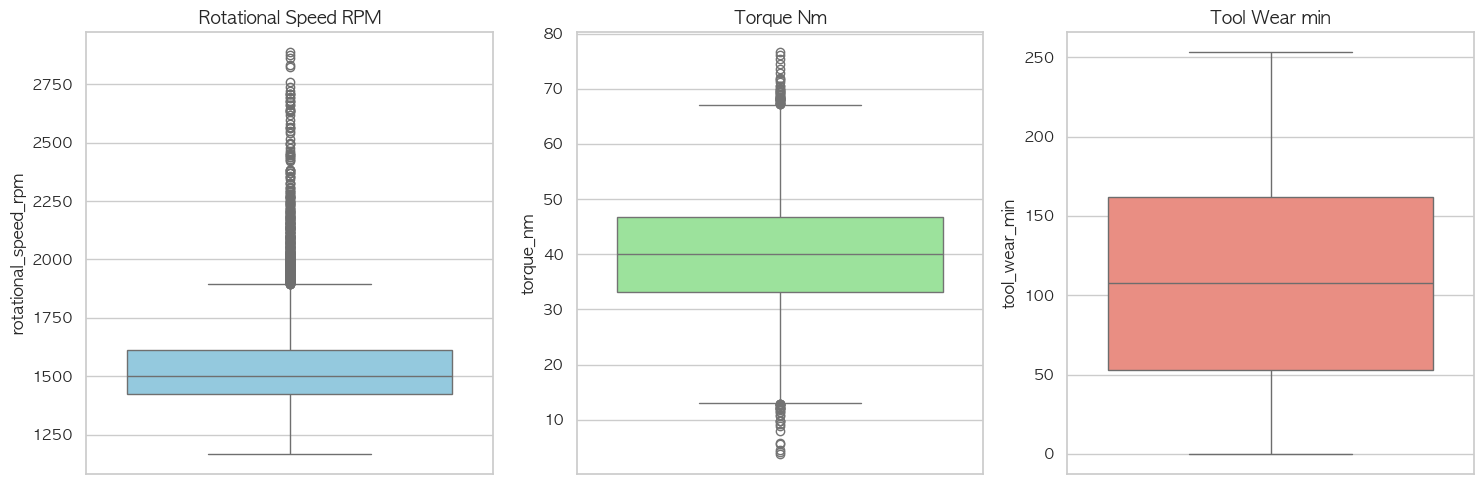

In [24]:
# 9. boxplot: 이상치 느낌 보기
plt.figure(figsize=(15, 5))

# 1. Rotational Speed (회전 속도)
plt.subplot(131)
sns.boxplot(y=df["rotational_speed_rpm"], color='skyblue')
plt.title("Rotational Speed RPM", fontsize=13, fontweight='bold')

# 2. Torque (토크)
plt.subplot(132)
sns.boxplot(y=df["torque_nm"], color='lightgreen')
plt.title("Torque Nm", fontsize=13, fontweight='bold')

# 3. Tool Wear (공구 마모)
plt.subplot(133)
sns.boxplot(y=df["tool_wear_min"], color='salmon')
plt.title("Tool Wear min", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 박스플롯 해석 포인트
- 가운데 선은 중앙값입니다.
- 상자 길이는 데이터가 주로 분포하는 구간입니다.
- 점처럼 바깥에 보이는 값은 이상치 후보입니다.
- 단, 제조 데이터의 이상치는 오류가 아니라 중요한 신호일 수도 있습니다.

In [25]:
# 10. 파생변수 생성
df["temp_diff"] = df["process_temp_k"] - df["air_temp_k"]
df["power_proxy"] = df["rotational_speed_rpm"] * df["torque_nm"]
df["tool_wear_group"] = pd.cut(
    df["tool_wear_min"],
    bins=[-1, 50, 150, 300],
    labels=["low", "mid", "high"]
)

display(df[[
    "air_temp_k", "process_temp_k", "temp_diff",
    "rotational_speed_rpm", "torque_nm", "power_proxy",
    "tool_wear_min", "tool_wear_group"
]])

,air_temp_k,process_temp_k,temp_diff,rotational_speed_rpm,torque_nm,power_proxy,tool_wear_min,tool_wear_group
0,298.100,308.600,10.500,1551,42.800,66382.800,0,low
1,298.200,308.700,10.500,1408,46.300,65190.400,3,low
2,298.100,308.500,10.400,1498,49.400,74001.200,5,low
3,298.200,308.600,10.400,1433,39.500,56603.500,7,low
4,298.200,308.700,10.500,1408,40.000,56320.000,9,low
...,...,...,...,...,...,...,...,...
9995,298.800,308.400,9.600,1604,29.500,47318.000,14,low
9996,298.900,308.400,9.500,1632,31.800,51897.600,17,low
9997,299.000,308.600,9.600,1645,33.400,54943.000,22,low
9998,299.000,308.700,9.700,1408,48.500,68288.000,25,low


### 파생변수 해석
- temp_diff: 공정 온도와 공기 온도의 차이
- power_proxy: 회전수와 토크를 함께 보는 단순 지표
- tool_wear_group: 연속형 변수를 low/mid/high 구간으로 바꾼 변수
- 현업에서는 이런 파생변수가 원본 변수보다 더 설명력이 좋을 수 있습니다.

In [26]:
# 11. 고장 여부별 평균 비교
group_mean = df.groupby("machine_failure")[num_cols + ["temp_diff", "power_proxy"]].mean().round(3)

print("고장 여부별 평균 비교")
display(group_mean)

고장 여부별 평균 비교


,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,temp_diff,power_proxy
machine_failure,,,,,,,
0,299.974,309.996,1540.260,39.630,106.694,10.022,59631.036
1,300.886,310.290,1496.487,50.168,143.782,9.404,69545.803


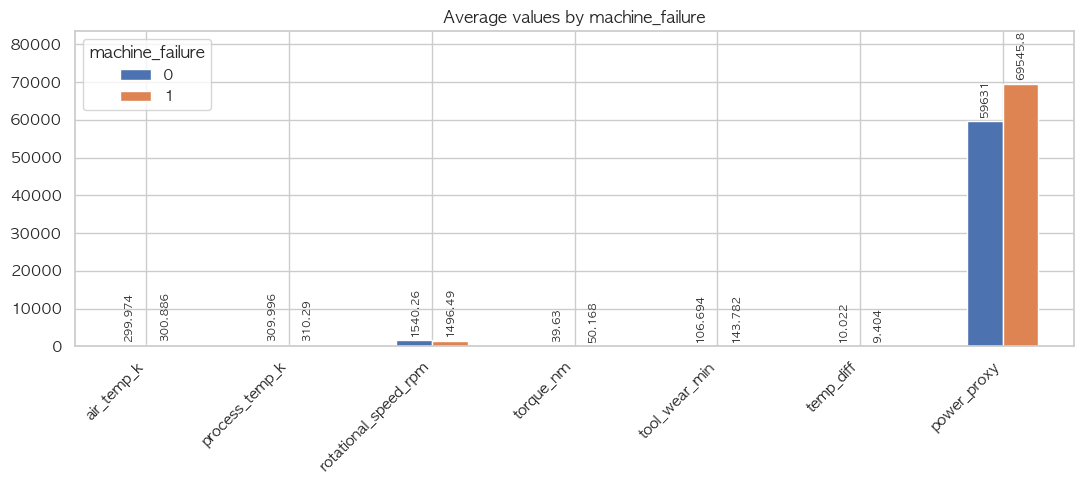

In [27]:
ax = group_mean.T.plot(kind="bar", figsize=(11, 5))
for i in ax.containers:
    ax.bar_label(i, padding=3, rotation=90, fontsize=8)
plt.margins(y=0.2) # 위쪽 공간 확보
plt.title("Average values by machine_failure")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 해석 포인트
- failure=1 그룹과 failure=0 그룹의 평균 차이를 확인합니다.
- 평균 차이가 있다고 바로 원인이라고 단정하면 안 되지만, 중요한 힌트가 됩니다.

# 🔍 고장 여부별 수치 변화 분석

기계의 정상 상태(`machine_failure=0`)와 고장 상태(`machine_failure=1`)일 때 주요 변수들의 평균값을 비교하여 고장의 결정적인 원인을 분석합니다.

### **1. 고장 여부별 평균 비교표**

| 변수명 | 정상 (0) | 고장 (1) | 증감 상태 | 비고 |
| :--- | :---: | :---: | :---: | :--- |
| **air_temp_k** | 299.97 | 300.88 | 🟢 소폭 상승 | 온도 영향 미미 |
| **process_temp_k** | 309.99 | 310.29 | 🟢 소폭 상승 | 공정 온도 안정적 |
| **rotational_speed_rpm** | **1540.26** | **1496.48** | 🔴 **감소** | 부하로 인한 속도 저하 |
| **torque_nm** | **39.63** | **50.16** | 🔺 **급격 상승** | **고장 핵심 지표** |
| **tool_wear_min** | **106.69** | **143.78** | 🔺 **급격 상승** | **유지보수 필요 신호** |
| **temp_diff** | 10.02 | 9.40 | 🔵 소폭 감소 | 열 배출 효율 저하 |
| **power_proxy** | **59,631.0** | **69,545.8** | 🔺 **급격 상승** | 과도한 에너지 소모 |

---

### **2. 데이터 기반 해석 및 인사이트**

#### **⚠️ 고장의 핵심 징후 (Critical Factors)**
* **토크(Torque)의 급격한 상승**: 고장 발생 시 토크 평균이 약 **26% 이상 증가**합니다. 장비에 비정상적인 부하가 걸리고 있음을 나타내는 가장 강력한 신호입니다.
* **공구 마모(Tool Wear) 누적**: 고장 그룹의 마모 시간은 평균 **143분**으로, 정상 그룹(106분)에 비해 훨씬 높습니다. 이는 약 140분을 기점으로 예방 정비가 필요함을 시사합니다.
* **동력 소모(Power Proxy) 증가**: 토크가 높아지면서 자연스럽게 소모되는 동력 수치도 약 **16% 증가**합니다.

#### **📉 상관 관계 특징**
* **역상관 관계**: 정상일 때보다 고장일 때 **회전 속도(RPM)는 오히려 낮아지는 경향**을 보입니다. 이는 높은 토크(부하)가 발생하면서 모터의 회전 효율을 떨어뜨리기 때문으로 해석됩니다.
* **온도 편차(Temp Diff)**: 고장 시 온도 차이가 소폭 줄어드는 것은 장비 내부의 열 배출이 원활하지 않아 내부 온도가 상승했음을 암시할 수 있습니다.

---

### **💡 향후 분석 방향**
1. **임계치 설정**: `torque_nm > 50` 또는 `tool_wear_min > 140` 구간에서 고장 확률이 얼마나 급증하는지 확률 밀도를 분석합니다.
2. **복합 요인 분석**: 단일 변수보다는 `Torque * Tool Wear`와 같은 파생 변수가 고장 예측 모델(`machine_failure` 예측)에서 높은 중요도를 가질 것으로 예상됩니다.

### **🔍 고장 여부별 평균 비교 분석**

고장 여부(`machine_failure`)에 따른 수치형 변수들의 평균 차이를 분석한 결과, 다음과 같은 특징이 발견되었습니다.

1. **과부하 징후 (Torque & Power)**
   - 고장 발생 시 **Torque**는 평균 약 **50.17 Nm**로, 정상(39.63 Nm) 대비 크게 높습니다.
   - **power_proxy** 역시 고장 시 약 **16.6% 증가**하여 장비에 과한 부하가 걸리고 있음을 알 수 있습니다.

2. **노후화 지표 (Tool Wear)**
   - **tool_wear_min**은 고장 그룹에서 평균 **143.78분**으로 나타났습니다. 
   - 이는 공구 마모가 일정 수준(약 140분)을 넘어서면 고장 위험이 급격히 증가함을 의미합니다.

3. **장비 거동 변화**
   - 고장이 발생할 때 **Rotational Speed**는 약 **1,496 RPM**으로 낮아지는 경향을 보입니다. 
   - 이는 높은 부하(Torque)로 인해 회전 효율이 떨어지는 현상으로 해석됩니다.

**결론:** 본 데이터셋에서 기계 고장을 예측하는 데 가장 핵심적인 피처는 **Torque, Tool Wear, Power Proxy**입니다.

In [28]:
# 12. 공구 마모 구간별 고장률
summary_wear = df.groupby("tool_wear_group").agg(
    count=("udi", "count"),
    avg_tool_wear=("tool_wear_min", "mean"),
    failure_rate=("machine_failure", "mean")
).round(3)

print("공구 마모 구간별 요약")
display(summary_wear)

공구 마모 구간별 요약


,count,avg_tool_wear,failure_rate
tool_wear_group,,,
low,2396,24.482,0.022
mid,4566,100.634,0.023
high,3038,184.779,0.061


## 🛠️ 공구 마모 구간별 고장 분석 (Tool Wear Analysis)

공구 마모 시간(`tool_wear`)을 세 구간으로 나누어 고장률(`failure_rate`)의 변화를 분석한 결과입니다.

### **1. 구간별 요약 통계**
| 마모 그룹 (`tool_wear_group`) | 데이터 수 (`count`) | 평균 마모 시간 (min) | **고장률 (`failure_rate`)** |
|:--- |:---:|:---:|:---:|
| **Low** (초기) | 2,396 | 24.48 | 2.2% |
| **Mid** (중기) | 4,566 | 100.63 | 2.3% |
| **High** (말기) | 3,038 | 184.78 | **6.1%** |

---

### **2. 핵심 인사이트**
* **지수적 고장 증가**: 마모도가 낮은 초기~중기 구간에서는 고장률이 2%대로 안정적이지만, **High 구간(평균 185분) 진입 시 고장 위험이 6% 이상으로 급격히 상승**합니다.
* **유지보수 임계점**: 데이터 분석 결과, 고장 방지를 위한 경제적인 공구 교체 시점은 **마모 시간 150분 전후**로 설정하는 것이 권장됩니다.
* **운영 전략**: 'Mid' 구간까지는 적극적인 가동이 가능하나, 'High' 구간 데이터는 고장 데이터의 비중이 높으므로 실시간 모니터링 강화가 필요합니다.

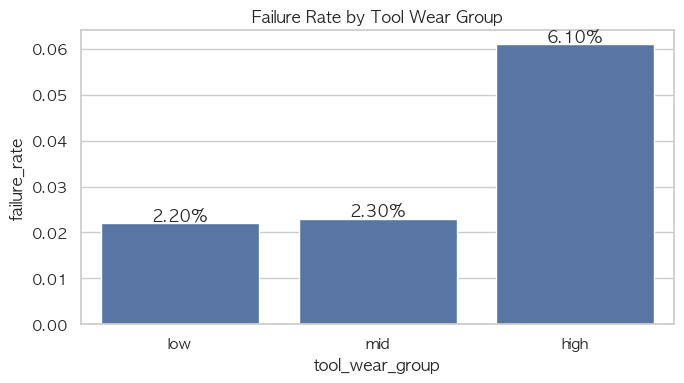

In [29]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(x=summary_wear.index.astype(str), y=summary_wear["failure_rate"])
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2%}")
plt.title("Failure Rate by Tool Wear Group")
plt.xlabel("tool_wear_group")
plt.ylabel("failure_rate")
plt.tight_layout()
plt.show()

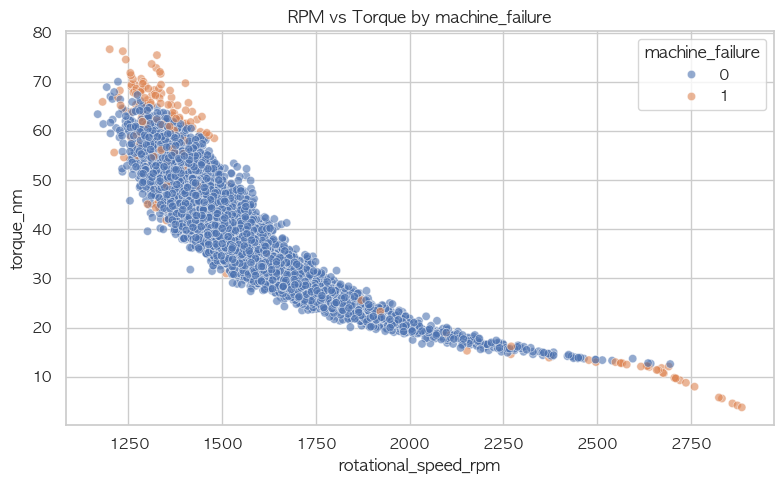

In [30]:
# 13. 산점도: rpm과 torque 관계
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="rotational_speed_rpm",
    y="torque_nm",
    hue="machine_failure",
    alpha=0.6
)
plt.title("RPM vs Torque by machine_failure")
plt.tight_layout()
plt.show()

### **📈 RPM vs Torque 산점도 분석 (고장 유무별)**

회전 속도(`rotational_speed_rpm`)와 토크(`torque_nm`)의 상관관계를 통해 고장 발생 패턴을 시각화한 결과입니다.

#### **1. 주요 시각화 결과 해석**
* **물리적 상관관계**: RPM과 Torque는 전형적인 **반비례 관계**를 보이며 곡선 형태의 분포를 형성하고 있습니다.
* **고장 밀집 구간 (High Torque)**: 
    - RPM 1,200 ~ 1,500 사이에서 **Torque가 60Nm를 초과**하는 시점에 고장(orange)이 집중적으로 발생합니다.
    - 이는 장비의 물리적 한계를 넘어서는 '과부하' 상태가 고장의 결정적 원인임을 보여줍니다.
* **고속 가동 위험 (High RPM)**:
    - RPM 2,500 이상의 고속 구간에서도 고장이 드문드문 발생하며, 이는 속도와 힘의 불균형이 장비 안정성을 해칠 수 있음을 의미합니다.

#### **2. 분석 인사이트**
* **핵심 피처**: `torque_nm`은 고장을 분류하는 가장 강력한 변수 중 하나입니다.
* **모델링 전략**: 정상 분포 곡선(Main Stream)을 벗어나는 상단 구간의 데이터를 감지하는 것이 고장 예측 모델의 핵심 성능 지표가 될 것입니다.
* **운영 가이드**: 장비 수명을 위해 **Torque가 60Nm 이상으로 치솟지 않도록** 가동 조건을 제어하거나, 해당 구간 진입 시 즉시 알람을 울리는 로직이 필요합니다.

In [31]:
# 14. seaborn heatmap: 상관관계
corr_cols = num_cols + ["temp_diff", "power_proxy", "machine_failure"]
corr = df[corr_cols].corr().round(2)

print("상관계수 표")
display(corr)

상관계수 표


,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,temp_diff,power_proxy,machine_failure
air_temp_k,1.000,0.880,0.020,-0.010,0.010,-0.700,-0.010,0.080
process_temp_k,0.880,1.000,0.020,-0.010,0.010,-0.270,-0.010,0.040
rotational_speed_rpm,0.020,0.020,1.000,-0.880,0.000,-0.020,-0.810,-0.040
torque_nm,-0.010,-0.010,-0.880,1.000,-0.000,0.010,0.980,0.190
tool_wear_min,0.010,0.010,0.000,-0.000,1.000,-0.010,-0.000,0.110
temp_diff,-0.700,-0.270,-0.020,0.010,-0.010,1.000,0.010,-0.110
power_proxy,-0.010,-0.010,-0.810,0.980,-0.000,0.010,1.000,0.180
machine_failure,0.080,0.040,-0.040,0.190,0.110,-0.110,0.180,1.000


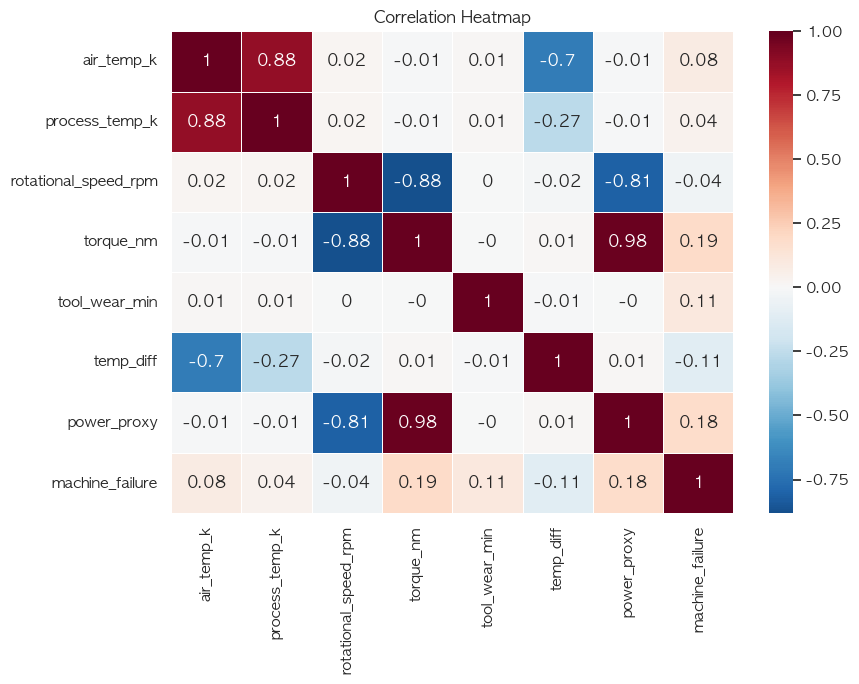

In [32]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### heatmap 해석 포인트
- 1에 가까울수록 양의 상관, -1에 가까울수록 음의 상관입니다.
- machine_failure와 상대적으로 관련이 있어 보이는 변수를 탐색할 수 있습니다.
- 상관관계는 인과관계를 뜻하지 않으며, 탐색의 출발점으로 보는 것이 중요합니다.

In [33]:
# 15. type별 평균 비교
type_summary = df.groupby("type").agg(
    count=("udi", "count"),
    avg_air_temp=("air_temp_k", "mean"),
    avg_process_temp=("process_temp_k", "mean"),
    avg_rpm=("rotational_speed_rpm", "mean"),
    avg_torque=("torque_nm", "mean"),
    avg_tool_wear=("tool_wear_min", "mean"),
    failure_rate=("machine_failure", "mean")
).round(3)

print("제품 type별 요약")
display(type_summary)

제품 type별 요약


,count,avg_air_temp,avg_process_temp,avg_rpm,avg_torque,avg_tool_wear,failure_rate
type,,,,,,,
H,1003,299.867,309.926,1538.148,39.838,107.420,0.021
L,6000,300.016,310.012,1539.469,39.997,108.379,0.039
M,2997,300.029,310.019,1537.599,40.017,107.272,0.028


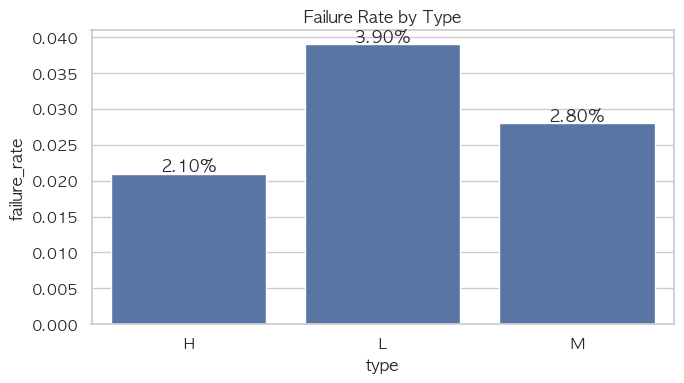

In [34]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(x=type_summary.index, y=type_summary["failure_rate"])
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2%}")
plt.title("Failure Rate by Type")
plt.tight_layout()
plt.show()

In [35]:
# 16. 간단한 통계 검정 예시
# 고장 여부에 따라 torque 평균 차이가 있는지 t-test 예시
failure_0 = df[df["machine_failure"] == 0]["torque_nm"]
failure_1 = df[df["machine_failure"] == 1]["torque_nm"]

t_stat, p_value = stats.ttest_ind(failure_0, failure_1, equal_var=False)

print("간단한 통계 검정 예시: torque_nm의 두 그룹 평균 비교")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value    : {p_value:.6f}")

if p_value < 0.05:
    print("해석: 두 그룹의 평균 차이가 통계적으로 유의하다고 볼 수 있습니다.")
else:
    print("해석: 두 그룹의 평균 차이가 통계적으로 유의하다고 보기 어렵습니다.")

print("\n주의:")
print("- p-value가 작다고 해서 '원인'이라고 단정할 수는 없습니다.")
print("- 여기서는 '차이가 있는지 탐색한다'는 관점으로 이해하면 충분합니다.")

간단한 통계 검정 예시: torque_nm의 두 그룹 평균 비교
t-statistic: -11.781
p-value    : 0.000000
해석: 두 그룹의 평균 차이가 통계적으로 유의하다고 볼 수 있습니다.

주의:
- p-value가 작다고 해서 '원인'이라고 단정할 수는 없습니다.
- 여기서는 '차이가 있는지 탐색한다'는 관점으로 이해하면 충분합니다.


In [36]:
# 17. 이상치 개수 확인(IQR)
print("이상치 의심 개수(IQR 방식)")
outlier_result = []

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_result.append([col, outlier_count, lower, upper])

outlier_df = pd.DataFrame(
    outlier_result,
    columns=["column", "outlier_count", "lower_bound", "upper_bound"]
).round(3)

display(outlier_df)

이상치 의심 개수(IQR 방식)


,column,outlier_count,lower_bound,upper_bound
0,air_temp_k,0,293.500,306.300
1,process_temp_k,0,305.350,314.550
2,rotational_speed_rpm,418,1139.500,1895.500
3,torque_nm,69,12.800,67.200
4,tool_wear_min,0,-110.500,325.500


## 📏 IQR 방식의 이상치 탐지 원리 (1.5 * IQR)

박스플롯(Boxplot) 기반의 이상치 탐지에서 사용되는 **1.5 * IQR** 법칙에 대한 상세 설명입니다.

### **1. 주요 개념 정의**
* **IQR (사분범위)**: $Q3(75\% 지점) - Q1(25\% 지점)$. 데이터의 핵심적인 '몸통' 구간의 길이입니다.
* **Upper Bound (상한선)**: $Q3 + (1.5 \times IQR)$
* **Lower Bound (하한선)**: $Q1 - (1.5 \times IQR)$

### **2. 1.5의 의미와 역할**
* **데이터의 울타리**: 이 범위를 벗어나는 데이터는 전체의 약 0.7%에 해당하며, 통계적으로 **일반적인 범주를 벗어난 값**으로 간주합니다.
* **이상치 후보 선정**: 1.5배수를 넘는 값들은 단순한 변동이 아닌, 시스템 오류나 특이 현상(예: 장비 고장 전조)일 가능성이 높다고 판단하여 분석가의 확인을 유도합니다.

### **3. 분석 시 주의사항**
* **도메인 지식 우선**: 기계 데이터에서 IQR 범위를 벗어난 값이 반드시 제거 대상인 '노이즈'는 아닙니다. 오히려 **고장 발생 직전의 중요한 신호**일 수 있으므로, 삭제 전 반드시 원본 데이터를 대조해야 합니다.
* **분포의 영향**: 데이터가 한쪽으로 심하게 치우친(Skewed) 경우, IQR 방식이 이상치를 과도하게 잡아낼 수 있으므로 시각화 결과와 병행해서 판단해야 합니다.

In [37]:
# 18. 인코딩 및 데이터 분리
df_encoded = pd.get_dummies(
    df,
    columns=["type", "tool_wear_group"],
    drop_first=True
)

X = df_encoded.drop(columns=["machine_failure", "product_id", "product_code"], errors="ignore")
y = df_encoded["machine_failure"]

print("\n인코딩 후 데이터 크기")
print("X shape:", X.shape)
print("y shape:", y.shape)

display(y.value_counts().to_frame("count"))


인코딩 후 데이터 크기
X shape: (10000, 18)
y shape: (10000,)


,count
machine_failure,
0,9661
1,339


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("train / test 분리 결과")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train failure rate:", round(y_train.mean(), 4))
print("y_test  failure rate:", round(y_test.mean(), 4))

train / test 분리 결과
X_train: (8000, 18)
X_test : (2000, 18)
y_train failure rate: 0.0339
y_test  failure rate: 0.034


In [39]:
try:
    import mglearn
except:
    %pip install mglearn
    # Successfully installed imageio-2.37.3 mglearn-0.2.0

In [40]:
import mglearn

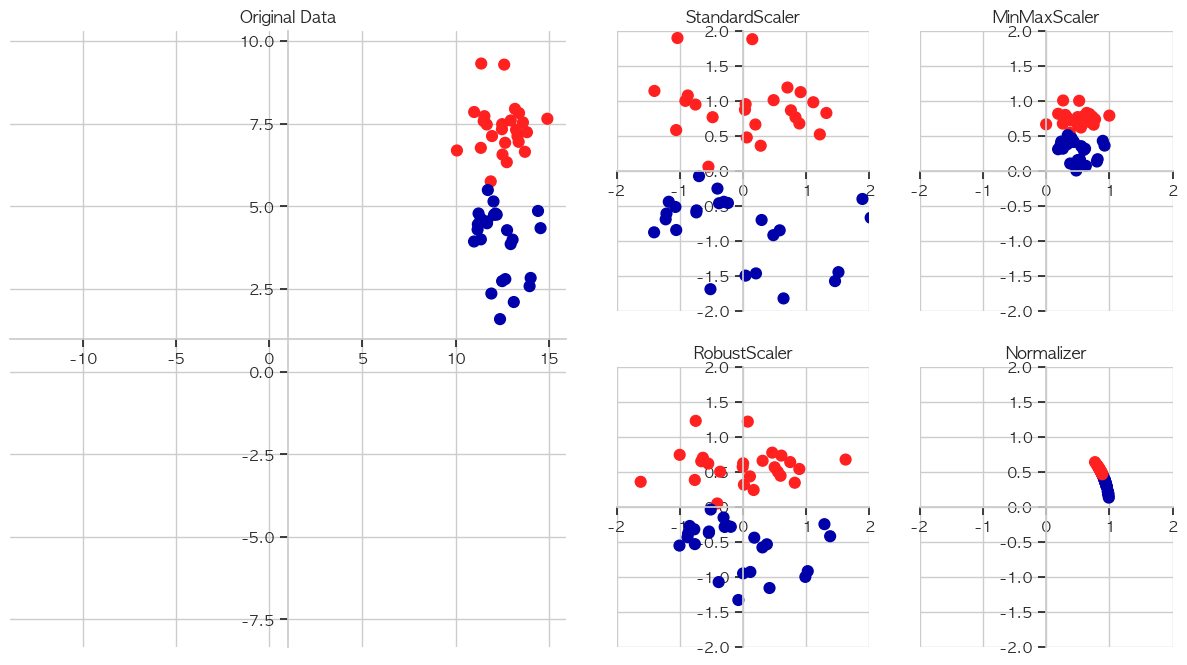

In [41]:
mglearn.plots.plot_scaling()

In [42]:
# 19. 스케일링
scale_cols = [
    "air_temp_k",
    "process_temp_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "temp_diff",
    "power_proxy"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print("스케일링 후 일부 데이터")
display(X_train_scaled[scale_cols].head())

스케일링 후 일부 데이터


,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,temp_diff,power_proxy
4058,0.999,0.604,-0.461,0.718,-0.844,-1.101,0.852
1221,-1.505,-1.153,-0.776,0.638,0.382,1.300,0.480
6895,0.498,1.077,-1.008,0.559,0.461,0.600,0.184
9863,-0.554,-0.139,-0.709,1.627,-0.372,0.900,1.899
8711,-1.455,-1.018,1.070,-1.128,-0.907,1.400,-1.002


In [43]:
print("해석:")
print("- 스케일링은 변수 단위를 맞춰 주는 과정입니다.")
print("- 특히 거리 기반 또는 가중치 학습 모델에서 중요할 수 있습니다.")
print("- fit은 train 데이터에만 하고, test에는 transform만 적용해야 데이터 누수를 줄일 수 있습니다.")

해석:
- 스케일링은 변수 단위를 맞춰 주는 과정입니다.
- 특히 거리 기반 또는 가중치 학습 모델에서 중요할 수 있습니다.
- fit은 train 데이터에만 하고, test에는 transform만 적용해야 데이터 누수를 줄일 수 있습니다.


In [44]:
# 20. 저장
save_path = output_dir / "day1_ai4i_enhanced_preprocessed.csv"
df_encoded.to_csv(save_path, index=False, encoding="utf-8-sig")

print("저장 완료:", save_path)

저장 완료: output/day1_ai4i_enhanced_preprocessed.csv



ML 맛보기: Decision Tree로 간단한 고장 예측

설명:
- machine_failure(고장 여부)를 예측해보겠습니다.
- 오늘 만든 전처리 데이터와 파생변수가 실제 예측 문제에 연결되는지 확인하는 단계입니다.
- 성능을 높이는 것이 목적이 아니라, 데이터 준비의 의미를 체감하는 것이 목적입니다.
- Decision Tree는 조건을 나누어가며 예측하는 모델이라 초보자도 이해하기 좋습니다.

모델 학습 완료
- train 데이터로 분기 규칙을 학습했습니다.
- 이제 test 데이터로 예측 성능을 간단히 확인합니다.

=== 정확도(accuracy) ===
accuracy: 0.9990

해석:
- accuracy는 전체 예측 중 맞춘 비율입니다.
- 하지만 고장 데이터 비율이 낮으면 accuracy만 높게 나올 수도 있습니다.
- 따라서 혼동행렬과 recall도 함께 보는 것이 중요합니다.

=== 혼동행렬(confusion matrix) ===


,Pred 0,Pred 1
Actual 0,1932,0
Actual 1,2,66


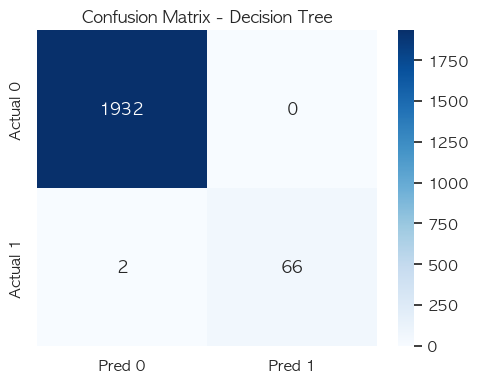


혼동행렬 해석 포인트
- Actual 0 / Pred 0: 실제 정상인데 정상으로 맞춘 경우
- Actual 1 / Pred 1: 실제 고장인데 고장으로 맞춘 경우
- Actual 1 / Pred 0: 실제 고장을 놓친 경우
- 제조에서는 고장을 놓치는 비용이 클 수 있으므로 이 부분이 중요합니다.

=== classification report ===


,precision,recall,f1-score,support
0,0.999,1.000,0.999,1932.000
1,1.000,0.971,0.985,68.000
accuracy,0.999,0.999,0.999,0.999
macro avg,0.999,0.985,0.992,2000.000
weighted avg,0.999,0.999,0.999,2000.000



지표 해석 포인트
- precision: 고장이라고 예측한 것 중 실제 고장의 비율
- recall   : 실제 고장 중에서 모델이 잡아낸 비율
- f1-score : precision과 recall을 함께 본 균형 지표
- support  : 각 클래스의 실제 개수

특히 recall(고장 클래스 기준)이 중요할 수 있습니다.
이유: 제조 현장에서는 고장을 놓치는 것이 더 큰 문제일 수 있기 때문입니다.

=== 예측 결과 일부 보기 ===


,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,temp_diff,power_proxy,actual_failure,pred_failure,pred_proba_failure
2997,300.500,309.800,1345,62.700,153,9.300,84331.500,0,0,0.001
4871,303.700,312.400,1513,40.100,135,8.700,60671.300,0,0,0.001
3858,302.500,311.400,1559,37.600,209,8.900,58618.400,0,0,0.001
951,295.600,306.300,1509,35.800,60,10.700,54022.200,0,0,0.001
6463,300.500,310.000,1358,60.400,102,9.500,82023.200,0,0,0.001
3264,301.300,310.100,1455,44.100,188,8.800,64165.500,0,0,0.001
4508,302.400,310.000,1426,46.600,102,7.600,66451.600,0,0,0.001
2100,299.300,309.300,1471,46.000,42,10.000,67666.000,0,0,0.001
7885,300.700,312.300,1590,36.300,93,11.600,57717.000,0,0,0.001
2421,298.900,308.200,2384,15.000,19,9.300,35760.000,0,0,0.001



해석:
- pred_proba_failure는 '고장일 가능성'을 0~1 사이 값으로 보여줍니다.
- 실무에서는 단순 0/1 예측뿐 아니라 위험도 점수처럼 활용할 수도 있습니다.

=== 변수 중요도 상위 10개 ===


,feature,importance
7,hdf,0.318
8,pwf,0.302
9,osf,0.246
6,twf,0.133
11,type_match,0.000
16,tool_wear_group_mid,0.000
15,type_M,0.000
14,type_L,0.000
13,power_proxy,0.000
12,temp_diff,0.000


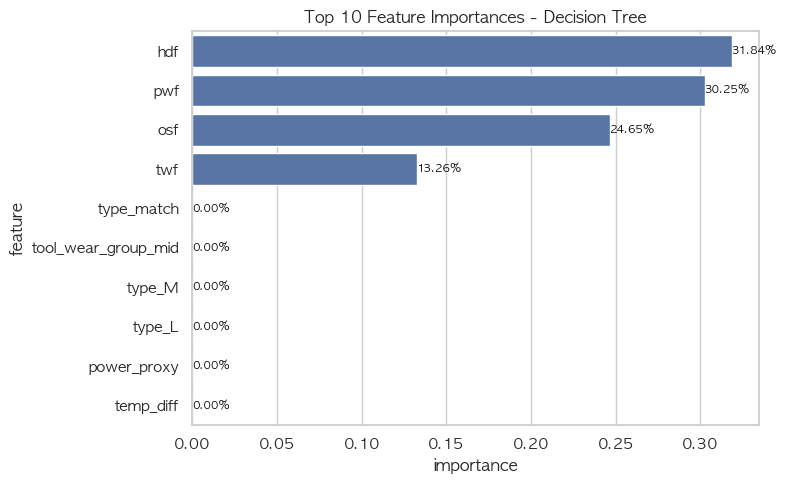


해석:
- 변수 중요도는 트리가 분기할 때 상대적으로 많이 참고한 변수를 뜻합니다.
- 중요도가 높다고 해서 원인을 증명하는 것은 아니지만,
  어떤 변수가 예측에 더 많이 쓰였는지 이해하는 데 도움이 됩니다.

간단 해석:
이번 트리 모델에서 상대적으로 중요하게 본 변수 예시: ['hdf', 'pwf', 'osf', 'twf', 'type_match']

강의 포인트:
- Decision Tree는 '어떤 조건에서 나뉘는가'를 이해하기 쉬운 모델입니다.
- 데이터 전처리와 파생변수가 모델 입력으로 실제 사용된다는 점을 확인할 수 있습니다.
- 다만 트리는 과적합되기 쉬워서, 깊이를 너무 크게 하면 train에만 잘 맞을 수 있습니다.

1일차 정리
오늘은 데이터를
1) 읽고
2) 이해하고
3) 시각화하고
4) 파생변수를 만들고
5) 전처리한 뒤
6) 간단한 예측까지 연결해봤습니다.

핵심 메시지:
- 모델보다 먼저 데이터 이해가 중요합니다.
- 좋은 전처리와 파생변수가 예측의 출발점입니다.
- accuracy 하나만 보지 말고, 고장을 얼마나 잘 잡는지도 함께 봐야 합니다.
- Decision Tree는 이해하기 쉬운 입문 모델이지만, 과적합에 주의해야 합니다.


In [45]:
# ---------------------------------------------------------
# 21. ML 맛보기: 전처리한 데이터를 이용한 간단한 고장 예측
# Decision Tree 버전
# 1일차에서는 '모델링 입문'이 아니라
# '오늘 만든 데이터가 실제 예측 문제로 연결된다'는 점을 체험하는 것이 목적
# ---------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\n" + "=" * 60)
print("ML 맛보기: Decision Tree로 간단한 고장 예측")
print("=" * 60)

print("\n설명:")
print("- machine_failure(고장 여부)를 예측해보겠습니다.")
print("- 오늘 만든 전처리 데이터와 파생변수가 실제 예측 문제에 연결되는지 확인하는 단계입니다.")
print("- 성능을 높이는 것이 목적이 아니라, 데이터 준비의 의미를 체감하는 것이 목적입니다.")
print("- Decision Tree는 조건을 나누어가며 예측하는 모델이라 초보자도 이해하기 좋습니다.")

# ---------------------------------------------------------
# 22. 모델 준비
# max_depth를 너무 크게 하면 과적합되기 쉬우므로
# 1일차에서는 적당히 제한해서 사용
# ---------------------------------------------------------
tree_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=20,
    random_state=42
)

# Decision Tree는 스케일링이 꼭 필요하지는 않으므로
# 원본 X_train / X_test를 사용
tree_model.fit(X_train, y_train)

print("\n모델 학습 완료")
print("- train 데이터로 분기 규칙을 학습했습니다.")
print("- 이제 test 데이터로 예측 성능을 간단히 확인합니다.")

# 예측
y_pred = tree_model.predict(X_test)
y_proba = tree_model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# 23. 기본 성능 확인
# ---------------------------------------------------------
acc = accuracy_score(y_test, y_pred)

print("\n=== 정확도(accuracy) ===")
print(f"accuracy: {acc:.4f}")

print("\n해석:")
print("- accuracy는 전체 예측 중 맞춘 비율입니다.")
print("- 하지만 고장 데이터 비율이 낮으면 accuracy만 높게 나올 수도 있습니다.")
print("- 따라서 혼동행렬과 recall도 함께 보는 것이 중요합니다.")

# ---------------------------------------------------------
# 24. 혼동행렬(confusion matrix)
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)

print("\n=== 혼동행렬(confusion matrix) ===")
display(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

print("\n혼동행렬 해석 포인트")
print("- Actual 0 / Pred 0: 실제 정상인데 정상으로 맞춘 경우")
print("- Actual 1 / Pred 1: 실제 고장인데 고장으로 맞춘 경우")
print("- Actual 1 / Pred 0: 실제 고장을 놓친 경우")
print("- 제조에서는 고장을 놓치는 비용이 클 수 있으므로 이 부분이 중요합니다.")

# ---------------------------------------------------------
# 25. classification report
# ---------------------------------------------------------
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T.round(3)

print("\n=== classification report ===")
display(report_df)

print("\n지표 해석 포인트")
print("- precision: 고장이라고 예측한 것 중 실제 고장의 비율")
print("- recall   : 실제 고장 중에서 모델이 잡아낸 비율")
print("- f1-score : precision과 recall을 함께 본 균형 지표")
print("- support  : 각 클래스의 실제 개수")

print("\n특히 recall(고장 클래스 기준)이 중요할 수 있습니다.")
print("이유: 제조 현장에서는 고장을 놓치는 것이 더 큰 문제일 수 있기 때문입니다.")

# ---------------------------------------------------------
# 26. 예측 결과 일부 보기
# ---------------------------------------------------------
result_preview = X_test.copy()
result_preview["actual_failure"] = y_test.values
result_preview["pred_failure"] = y_pred
result_preview["pred_proba_failure"] = y_proba.round(4)

print("\n=== 예측 결과 일부 보기 ===")
display(result_preview[[
    "air_temp_k",
    "process_temp_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "temp_diff",
    "power_proxy",
    "actual_failure",
    "pred_failure",
    "pred_proba_failure"
]].head(10))

print("\n해석:")
print("- pred_proba_failure는 '고장일 가능성'을 0~1 사이 값으로 보여줍니다.")
print("- 실무에서는 단순 0/1 예측뿐 아니라 위험도 점수처럼 활용할 수도 있습니다.")

# ---------------------------------------------------------
# 27. 변수 중요도(feature importance)
# Decision Tree에서는 계수 대신 중요도를 볼 수 있음
# ---------------------------------------------------------
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n=== 변수 중요도 상위 10개 ===")
display(importance_df.head(10))

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=importance_df.head(10), x="importance", y="feature")
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2%}", fontsize=8, color="black", fontweight="bold")
plt.title("Top 10 Feature Importances - Decision Tree")
plt.tight_layout()
plt.show()

print("\n해석:")
print("- 변수 중요도는 트리가 분기할 때 상대적으로 많이 참고한 변수를 뜻합니다.")
print("- 중요도가 높다고 해서 원인을 증명하는 것은 아니지만,")
print("  어떤 변수가 예측에 더 많이 쓰였는지 이해하는 데 도움이 됩니다.")

# ---------------------------------------------------------
# 28. 아주 간단한 모델 해석
# ---------------------------------------------------------
print("\n간단 해석:")
top_features = importance_df.head(5)["feature"].tolist()
print("이번 트리 모델에서 상대적으로 중요하게 본 변수 예시:", top_features)

print("\n강의 포인트:")
print("- Decision Tree는 '어떤 조건에서 나뉘는가'를 이해하기 쉬운 모델입니다.")
print("- 데이터 전처리와 파생변수가 모델 입력으로 실제 사용된다는 점을 확인할 수 있습니다.")
print("- 다만 트리는 과적합되기 쉬워서, 깊이를 너무 크게 하면 train에만 잘 맞을 수 있습니다.")

# ---------------------------------------------------------
# 29. 1일차 마무리 메시지
# ---------------------------------------------------------
print("\n" + "=" * 60)
print("1일차 정리")
print("=" * 60)
print("오늘은 데이터를")
print("1) 읽고")
print("2) 이해하고")
print("3) 시각화하고")
print("4) 파생변수를 만들고")
print("5) 전처리한 뒤")
print("6) 간단한 예측까지 연결해봤습니다.")

print("\n핵심 메시지:")
print("- 모델보다 먼저 데이터 이해가 중요합니다.")
print("- 좋은 전처리와 파생변수가 예측의 출발점입니다.")
print("- accuracy 하나만 보지 말고, 고장을 얼마나 잘 잡는지도 함께 봐야 합니다.")
print("- Decision Tree는 이해하기 쉬운 입문 모델이지만, 과적합에 주의해야 합니다.")

In [46]:
# end